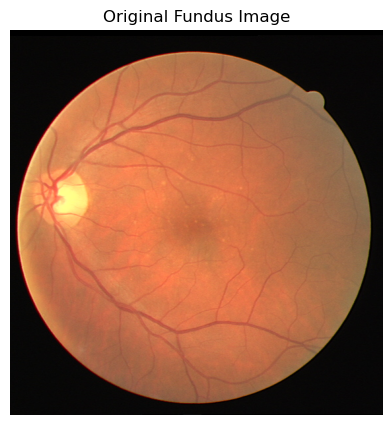

In [136]:
# RETINAL BLOOD VESSEL SEGMENTATION PIPELINE 
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage import img_as_bool, img_as_ubyte
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score
import imageio.v2 as imageio

# Set up folders 
INPUT_FOLDER = 'drive_training_Images/'
GROUNDTRUTH_FOLDER = 'drive_training-groundtruths/'
PREPROC_FOLDER = 'preprocessed/'
RESULT_FOLDER = 'results/segmented_enhanced/'

os.makedirs(PREPROC_FOLDER + 'gray', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'clahe', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'od_removed', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'blurred', exist_ok=True)
os.makedirs(RESULT_FOLDER, exist_ok=True)

# Select a sample image for visualization 
sample_image = '21_training.tif'
sample_base = os.path.splitext(sample_image)[0]

# Load and visualize original 
original_img = Image.open(os.path.join(INPUT_FOLDER, sample_image))
plt.figure(figsize=(5, 5))
plt.imshow(original_img)
plt.axis('off')
plt.title("Original Fundus Image")
plt.show()


In [137]:
# PREPROCESSING PIPELINE (AIM 1: Develop a preprocessing pipeline for retinal fundus images + OD removal)
for filename in os.listdir(INPUT_FOLDER):
    if filename.endswith(('.png', '.jpg', '.tif')):
        img_path = os.path.join(INPUT_FOLDER, filename)
        img = cv2.imread(img_path)
        if img is None:
            continue

        name, _ = os.path.splitext(filename)

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cv2.imwrite(f'{PREPROC_FOLDER}gray/{name}_gray.png', gray)

        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_img = clahe.apply(gray)
        cv2.imwrite(f'{PREPROC_FOLDER}clahe/{name}_clahe.png', clahe_img)

        _, thresh = cv2.threshold(clahe_img, 220, 255, cv2.THRESH_BINARY)

        kernel = np.ones((15, 15), np.uint8)
        closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask = np.zeros_like(clahe_img)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            cv2.drawContours(mask, [largest], -1, 255, -1)

        od_removed = clahe_img.copy()
        od_removed[mask == 255] = 0
        cv2.imwrite(f'{PREPROC_FOLDER}od_removed/{name}_od_removed.png', od_removed)

        blurred = cv2.GaussianBlur(od_removed, (5, 5), 0)
        cv2.imwrite(f'{PREPROC_FOLDER}blurred/{name}_blurred.png', blurred)

        print(f"Preprocessed: {filename}")


Preprocessed: 29_training.tif
Preprocessed: 28_training.tif
Preprocessed: 22_training.tif
Preprocessed: 25_training.tif
Preprocessed: 30_training.tif
Preprocessed: 37_training.tif
Preprocessed: 40_training.tif
Preprocessed: 36_training.tif
Preprocessed: 31_training.tif
Preprocessed: 24_training.tif
Preprocessed: 23_training.tif
Preprocessed: 33_training.tif
Preprocessed: 34_training.tif
Preprocessed: 21_training.tif
Preprocessed: 26_training.tif
Preprocessed: 27_training.tif
Preprocessed: 35_training.tif
Preprocessed: 32_training.tif
Preprocessed: 38_training.tif
Preprocessed: 39_training.tif


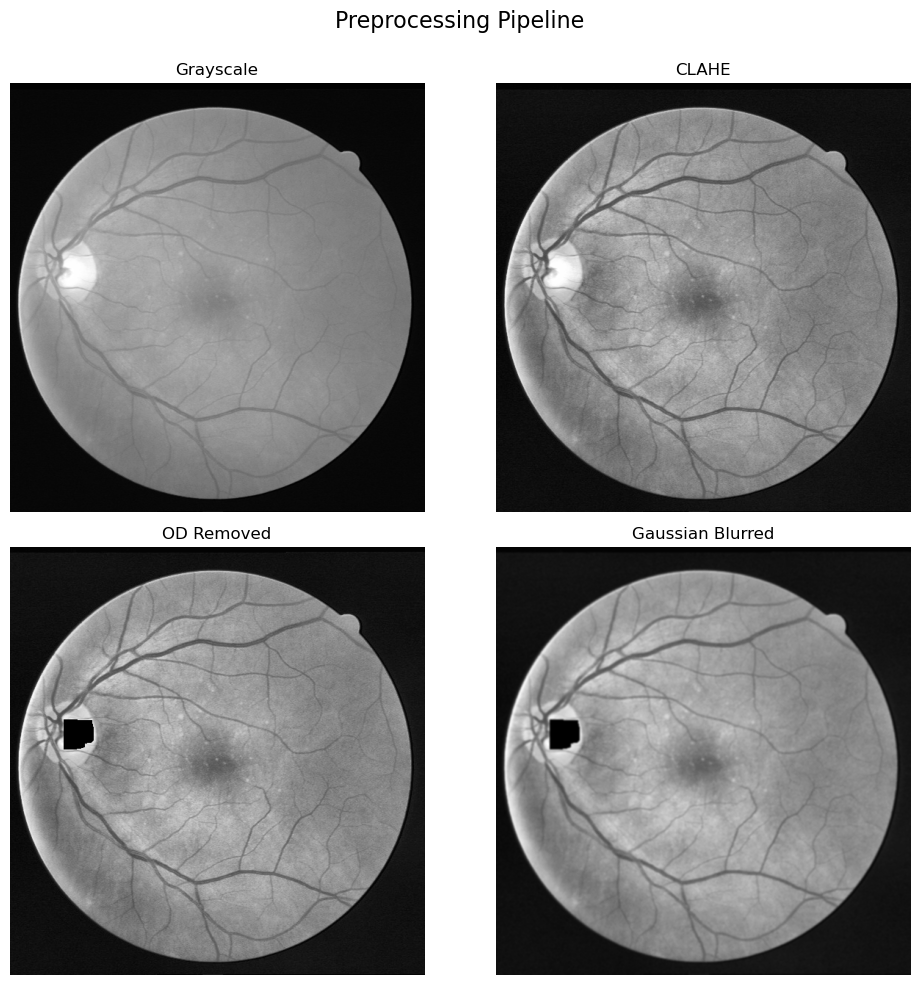

In [138]:
# DISPLAY PREPROCESSING STEPS FOR SAMPLE IMAGE 
sample_blur_path = f'{PREPROC_FOLDER}blurred/{sample_base}_blurred.png'
if os.path.exists(sample_blur_path):
    gray = cv2.imread(f'{PREPROC_FOLDER}gray/{sample_base}_gray.png', cv2.IMREAD_GRAYSCALE)
    clahe_img = cv2.imread(f'{PREPROC_FOLDER}clahe/{sample_base}_clahe.png', cv2.IMREAD_GRAYSCALE)
    od_removed = cv2.imread(f'{PREPROC_FOLDER}od_removed/{sample_base}_od_removed.png', cv2.IMREAD_GRAYSCALE)
    blurred = cv2.imread(sample_blur_path, cv2.IMREAD_GRAYSCALE)

    steps = [gray, clahe_img, od_removed, blurred]
    titles = ['Grayscale', 'CLAHE', 'OD Removed', 'Gaussian Blurred']
    plt.figure(figsize=(10, 10)) 

    for i, (img_step, title) in enumerate(zip(steps, titles)):
        plt.subplot(2, 2, i + 1)
        plt.imshow(img_step, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.suptitle("Preprocessing Pipeline", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    plt.show()

In [139]:
# SEGMENTATION PIPELINE (AIM 2: Implement and refine blood vessel segmentation techniques)
for filename in os.listdir(PREPROC_FOLDER + 'blurred'):
    if filename.endswith('.png'):
        path = os.path.join(PREPROC_FOLDER, 'blurred', filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                         cv2.THRESH_BINARY_INV, 15, 10)

        edges = cv2.Canny(img, 30, 90)

        combined = cv2.bitwise_or(adaptive, edges)

        kernel = np.ones((3, 3), np.uint8)
        morph = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
        morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel)

        skeleton = skeletonize(img_as_bool(morph))
        final = img_as_ubyte(skeleton)

        name, _ = os.path.splitext(filename)
        cv2.imwrite(os.path.join(RESULT_FOLDER, f'{name}_segmented.png'), final)
        print(f"Segmented: {filename}")

Segmented: 31_training_blurred.png
Segmented: 04_test_blurred.png
Segmented: 34_training_blurred.png
Segmented: 10_test_blurred.png
Segmented: 14_test_blurred.png
Segmented: 29_training_blurred.png
Segmented: 26_training_blurred.png
Segmented: 23_training_blurred.png
Segmented: 05_test_blurred.png
Segmented: 11_test_blurred.png
Segmented: 30_training_blurred.png
Segmented: 35_training_blurred.png
Segmented: 27_training_blurred.png
Segmented: 15_test_blurred.png
Segmented: 22_training_blurred.png
Segmented: 01_test_blurred.png
Segmented: 28_training_blurred.png
Segmented: 20_test_blurred.png
Segmented: 12_test_blurred.png
Segmented: 21_training_blurred.png
Segmented: 19_test_blurred.png
Segmented: 06_test_blurred.png
Segmented: 24_training_blurred.png
Segmented: 02_test_blurred.png
Segmented: 36_training_blurred.png
Segmented: 33_training_blurred.png
Segmented: 09_test_blurred.png
Segmented: 40_training_blurred.png
Segmented: 39_training_blurred.png
Segmented: 16_test_blurred.png
Segmen

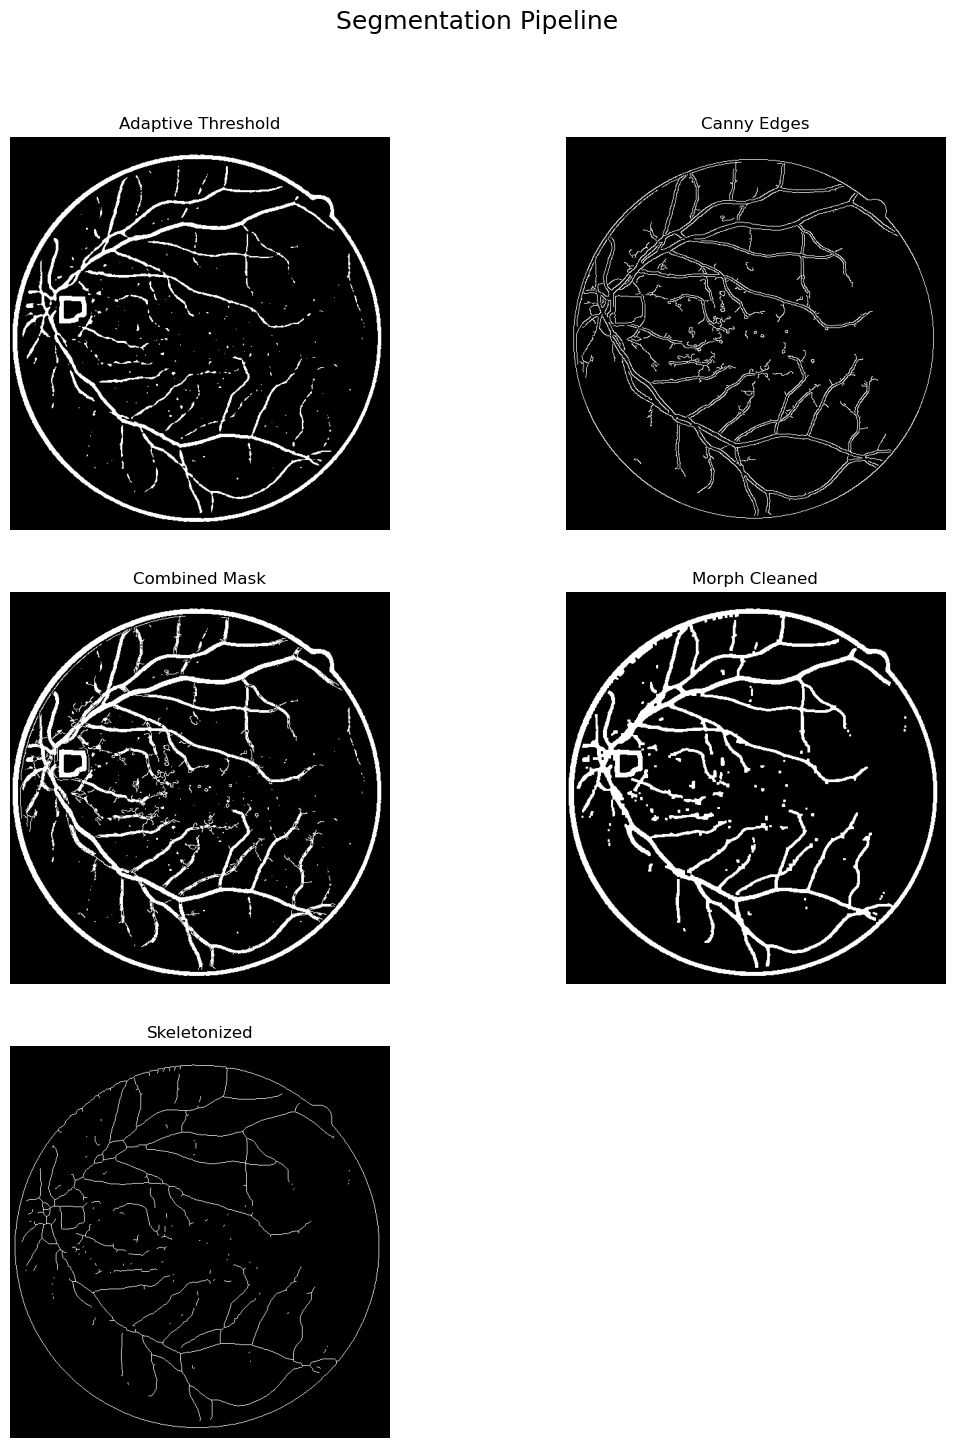

In [140]:
# DISPLAY SEGMENTATION STEPS FOR SAMPLE IMAGE 
if os.path.exists(sample_blur_path):
    img = cv2.imread(sample_blur_path, cv2.IMREAD_GRAYSCALE)
    adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY_INV, 15, 10)
    edges = cv2.Canny(img, 30, 90)
    combined = cv2.bitwise_or(adaptive, edges)
    kernel = np.ones((3, 3), np.uint8)
    morph = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel)
    skeleton = skeletonize(img_as_bool(morph))
    final = img_as_ubyte(skeleton)

    steps = [adaptive, edges, combined, morph, final]
    titles = ['Adaptive Threshold', 'Canny Edges', 'Combined Mask', 'Morph Cleaned', 'Skeletonized']
    plt.figure(figsize=(12, 15)) 
    for i, (img_step, title) in enumerate(zip(steps, titles)):
        plt.subplot(3, 2, i + 1)  # 3 rows, 2 columns
        plt.imshow(img_step, cmap='gray')
        plt.title(title)
        plt.axis('off')

    plt.suptitle("Segmentation Pipeline", fontsize=18)
    plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.98])  
    plt.show()

In [141]:
# EVALUATION METRICS

def dice_coefficient(gt, pred):
    intersection = np.sum((gt == 1) & (pred == 1))
    total = np.sum(gt == 1) + np.sum(pred == 1)
    return 2 * intersection / total if total else 1.0

dice_scores = []
accuracies = []
precisions = []
recalls = []

total_eval = 0
for i in range(21, 41):  # Loop from 21 to 40 inclusive
    base = f"{i:02d}"
    filename = f"{base}_training.tif"
    pred_name = f"{base}_training_blurred_segmented.png"  # <- UPDATED HERE
    gt_name = f"{base}_manual1.gif"

    gt_path = os.path.join(GROUNDTRUTH_FOLDER, gt_name)
    pred_path = os.path.join(RESULT_FOLDER, pred_name)

    print(f"Evaluating: {filename}")
    print(f"GT exists: {os.path.exists(gt_path)} | Pred exists: {os.path.exists(pred_path)}")

    if not (os.path.exists(gt_path) and os.path.exists(pred_path)):
        print(f"Missing pair for {base}")
        continue

    gt_mask = imageio.imread(gt_path)
    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

    gt_bin = (gt_mask > 0).astype(np.uint8).flatten()
    pred_bin = (pred_mask > 0).astype(np.uint8).flatten()

    dice_scores.append(dice_coefficient(gt_bin, pred_bin))
    accuracies.append(accuracy_score(gt_bin, pred_bin))
    precisions.append(precision_score(gt_bin, pred_bin, zero_division=1))
    recalls.append(recall_score(gt_bin, pred_bin, zero_division=1))
    total_eval += 1

print(f"\nTotal evaluated images: {total_eval}")
print("--- EVALUATION RESULTS ---")
print(f"Average Dice Coefficient: {np.mean(dice_scores):.4f}")
print(f"Average Accuracy:         {np.mean(accuracies):.4f}")
print(f"Average Precision:        {np.mean(precisions):.4f}")
print(f"Average Recall:           {np.mean(recalls):.4f}")


Evaluating: 21_training.tif
GT exists: True | Pred exists: True
Evaluating: 22_training.tif
GT exists: True | Pred exists: True
Evaluating: 23_training.tif
GT exists: True | Pred exists: True
Evaluating: 24_training.tif
GT exists: True | Pred exists: True
Evaluating: 25_training.tif
GT exists: True | Pred exists: True
Evaluating: 26_training.tif
GT exists: True | Pred exists: True
Evaluating: 27_training.tif
GT exists: True | Pred exists: True
Evaluating: 28_training.tif
GT exists: True | Pred exists: True
Evaluating: 29_training.tif
GT exists: True | Pred exists: True
Evaluating: 30_training.tif
GT exists: True | Pred exists: True
Evaluating: 31_training.tif
GT exists: True | Pred exists: True
Evaluating: 32_training.tif
GT exists: True | Pred exists: True
Evaluating: 33_training.tif
GT exists: True | Pred exists: True
Evaluating: 34_training.tif
GT exists: True | Pred exists: True
Evaluating: 35_training.tif
GT exists: True | Pred exists: True
Evaluating: 36_training.tif
GT exists: T

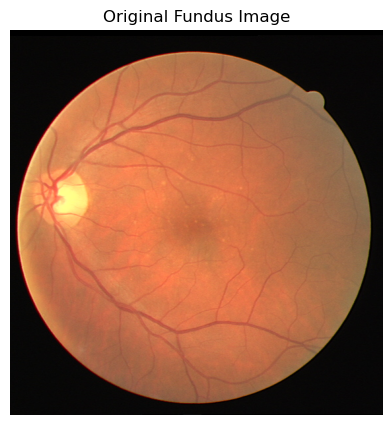

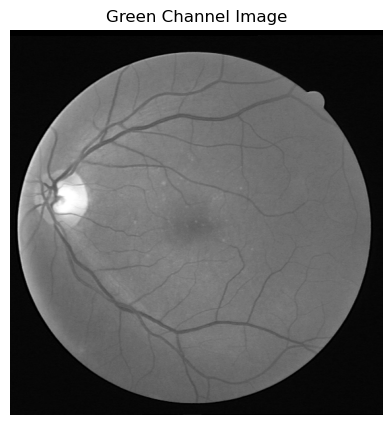

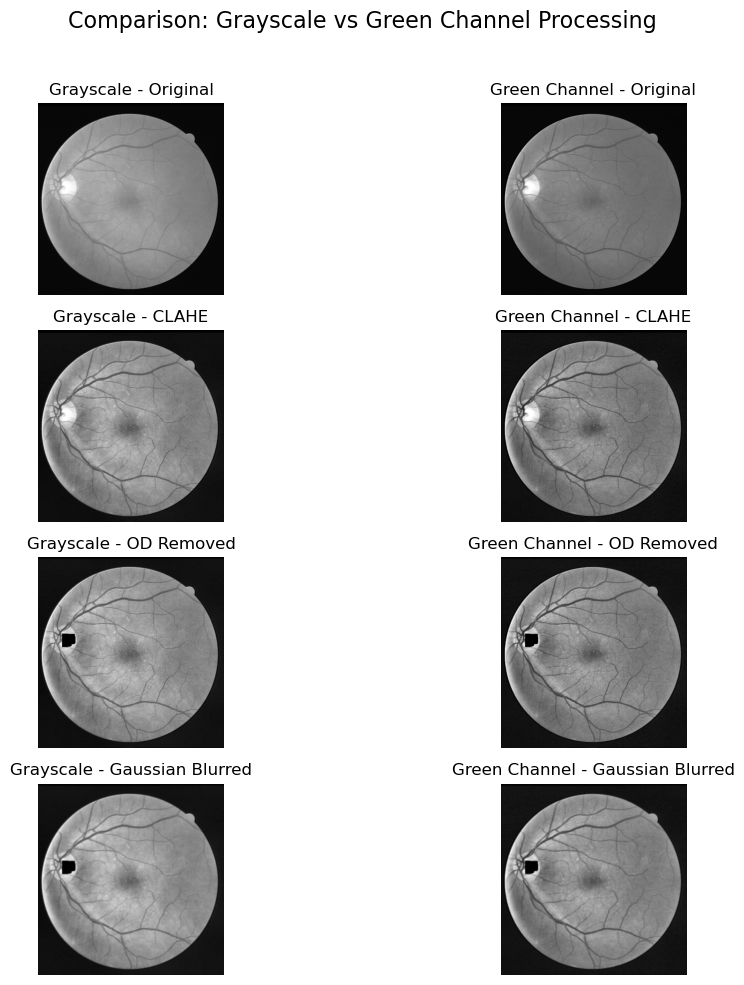

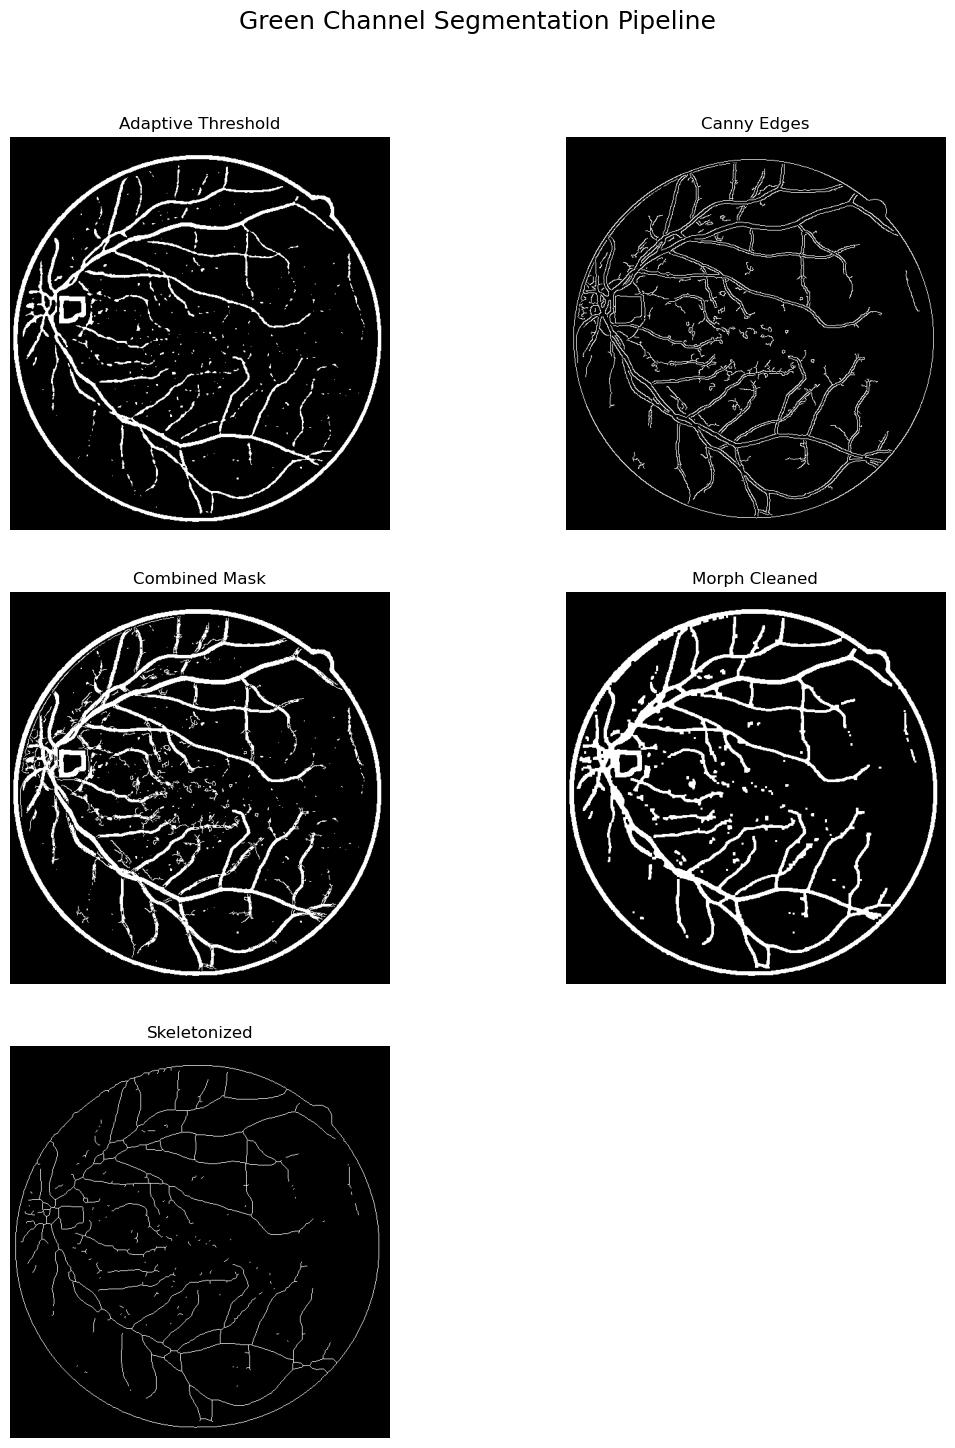


Total evaluated images: 20
--- GREEN CHANNEL EVALUATION RESULTS ---
Average Dice Coefficient: 0.2698
Average Accuracy:         0.9190
Average Precision:        0.6219
Average Recall:           0.1740


In [153]:
# GREEN CHANNEL EXTRACTION + EVALUATION + DISPLAY 
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage import img_as_bool, img_as_ubyte
from PIL import Image
import imageio.v2 as imageio
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Set up folders 
INPUT_FOLDER = 'drive_training_Images/'
GROUNDTRUTH_FOLDER = 'drive_training-groundtruths/'
PREPROC_FOLDER = 'preprocessed/'
RESULT_FOLDER = 'results/segmented_enhanced/'

os.makedirs(PREPROC_FOLDER + 'green_channel', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'green_channel_clahe', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'green_channel_od_removed', exist_ok=True)
os.makedirs(PREPROC_FOLDER + 'green_channel_blurred', exist_ok=True)
os.makedirs(RESULT_FOLDER + 'green', exist_ok=True)
os.makedirs(RESULT_FOLDER + 'gray', exist_ok=True)

# SAMPLE IMAGE DISPLAY (GREEN CHANNEL)
sample_image = '21_training.tif'
sample_base = os.path.splitext(sample_image)[0]

original_img = Image.open(os.path.join(INPUT_FOLDER, sample_image))
plt.figure(figsize=(5, 5))
plt.imshow(original_img)
plt.axis('off')
plt.title("Original Fundus Image")
plt.show()

# Convert to numpy array and extract green channel
green_channel = np.array(original_img)[:, :, 1]
cv2.imwrite(os.path.join(PREPROC_FOLDER, 'green_channel', sample_base + '_green.png'), green_channel)

plt.figure(figsize=(5, 5))
plt.imshow(green_channel, cmap='gray')
plt.axis('off')
plt.title("Green Channel Image")
plt.show()

# DISPLAY COMPARISON OF GRAYSCALE VS GREEN CHANNEL PREPROCESSING
if os.path.exists(f'{PREPROC_FOLDER}gray/{sample_base}_gray.png') and os.path.exists(f'{PREPROC_FOLDER}green_channel/{sample_base}_green.png'):
    gray = cv2.imread(f'{PREPROC_FOLDER}gray/{sample_base}_gray.png', cv2.IMREAD_GRAYSCALE)
    clahe_gray = cv2.imread(f'{PREPROC_FOLDER}clahe/{sample_base}_clahe.png', cv2.IMREAD_GRAYSCALE)
    od_removed_gray = cv2.imread(f'{PREPROC_FOLDER}od_removed/{sample_base}_od_removed.png', cv2.IMREAD_GRAYSCALE)
    blurred_gray = cv2.imread(f'{PREPROC_FOLDER}blurred/{sample_base}_blurred.png', cv2.IMREAD_GRAYSCALE)

    green = cv2.imread(f'{PREPROC_FOLDER}green_channel/{sample_base}_green.png', cv2.IMREAD_GRAYSCALE)
    clahe_green = cv2.imread(f'{PREPROC_FOLDER}green_channel_clahe/{sample_base}_green_clahe.png', cv2.IMREAD_GRAYSCALE)
    od_removed_green = cv2.imread(f'{PREPROC_FOLDER}green_channel_od_removed/{sample_base}_green_od_removed.png', cv2.IMREAD_GRAYSCALE)
    blurred_green = cv2.imread(f'{PREPROC_FOLDER}green_channel_blurred/{sample_base}_green_blurred.png', cv2.IMREAD_GRAYSCALE)

    steps_gray = [gray, clahe_gray, od_removed_gray, blurred_gray]
    steps_green = [green, clahe_green, od_removed_green, blurred_green]
    titles = ['Original', 'CLAHE', 'OD Removed', 'Gaussian Blurred']

    plt.figure(figsize=(12, 10)) 
    for i, (gray_step, green_step, title) in enumerate(zip(steps_gray, steps_green, titles)):
        plt.subplot(4, 2, 2 * i + 1)
        plt.imshow(gray_step, cmap='gray')
        plt.title(f"Grayscale - {title}")
        plt.axis('off')

        plt.subplot(4, 2, 2 * i + 2)
        plt.imshow(green_step, cmap='gray')
        plt.title(f"Green Channel - {title}")
        plt.axis('off')

    plt.suptitle("Comparison: Grayscale vs Green Channel Processing", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# DISPLAY GREEN CHANNEL SEGMENTATION PIPELINE STEPS
sample_blur_path = f'{PREPROC_FOLDER}green_channel_blurred/{sample_base}_green_blurred.png'
if os.path.exists(sample_blur_path):
    img = cv2.imread(sample_blur_path, cv2.IMREAD_GRAYSCALE)
    adaptive = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                     cv2.THRESH_BINARY_INV, 15, 10)
    edges = cv2.Canny(img, 30, 90)
    combined = cv2.bitwise_or(adaptive, edges)
    kernel = np.ones((3, 3), np.uint8)
    morph = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, kernel)
    morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel)
    skeleton = skeletonize(img_as_bool(morph))
    final = img_as_ubyte(skeleton)

    steps = [adaptive, edges, combined, morph, final]
    titles = ['Adaptive Threshold', 'Canny Edges', 'Combined Mask', 'Morph Cleaned', 'Skeletonized']

    plt.figure(figsize=(12, 15))
    for i, (img_step, title) in enumerate(zip(steps, titles)):
        plt.subplot(3, 2, i + 1)
        plt.imshow(img_step, cmap='gray')
        plt.title(title)
        plt.axis('off')

    plt.suptitle("Green Channel Segmentation Pipeline", fontsize=18)
    plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.98])
    plt.show()

# DISPLAY SEGMENTATION RESULTS COMPARISON
gray_result_path = os.path.join(RESULT_FOLDER, 'gray', f'{sample_base}_blurred_segmented.png')
green_result_path = os.path.join(RESULT_FOLDER, 'green', f'{sample_base}_green_blurred_segmented.png')

if os.path.exists(gray_result_path) and os.path.exists(green_result_path):
    gray_segmented = cv2.imread(gray_result_path, cv2.IMREAD_GRAYSCALE)
    green_segmented = cv2.imread(green_result_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(gray_segmented, cmap='gray')
    plt.title('Grayscale Segmentation')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(green_segmented, cmap='gray')
    plt.title('Green Channel Segmentation')
    plt.axis('off')

    plt.suptitle('Comparison: Grayscale vs Green Channel Segmentation', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Final overlay visualization
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(original_img)
    axs[0].set_title('Original Fundus')
    axs[0].axis('off')
    axs[1].imshow(original_img)
    axs[1].imshow(gray_segmented, cmap='Reds', alpha=0.5)
    axs[1].set_title('Overlay: Grayscale Segmentation')
    axs[1].axis('off')
    axs[2].imshow(original_img)
    axs[2].imshow(green_segmented, cmap='Greens', alpha=0.5)
    axs[2].set_title('Overlay: Green Channel Segmentation')
    axs[2].axis('off')
    plt.suptitle('Final Segmentation Overlays', fontsize=16)
    plt.tight_layout()
    plt.show()

# GREEN CHANNEL EVALUATION

def dice_coefficient(gt, pred):
    intersection = np.sum((gt == 1) & (pred == 1))
    total = np.sum(gt == 1) + np.sum(pred == 1)
    return 2 * intersection / total if total else 1.0

dice_scores = []
accuracies = []
precisions = []
recalls = []

total_eval = 0
for i in range(21, 41):
    base = f"{i:02d}"
    gt_path = os.path.join(GROUNDTRUTH_FOLDER, f"{base}_manual1.gif")
    pred_path = os.path.join(RESULT_FOLDER, 'green', f"{base}_training_green_blurred_segmented.png")

    if not (os.path.exists(gt_path) and os.path.exists(pred_path)):
        print(f"Missing pair for {base}")
        continue

    gt_mask = imageio.imread(gt_path)
    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)

    if gt_mask is None or pred_mask is None:
        continue

    gt_bin = (gt_mask > 0).astype(np.uint8).flatten()
    pred_bin = (pred_mask > 0).astype(np.uint8).flatten()

    dice_scores.append(dice_coefficient(gt_bin, pred_bin))
    accuracies.append(accuracy_score(gt_bin, pred_bin))
    precisions.append(precision_score(gt_bin, pred_bin, zero_division=1))
    recalls.append(recall_score(gt_bin, pred_bin, zero_division=1))
    total_eval += 1

print(f"\nTotal evaluated images: {total_eval}")
print("--- GREEN CHANNEL EVALUATION RESULTS ---")
print(f"Average Dice Coefficient: {np.mean(dice_scores):.4f}")
print(f"Average Accuracy:         {np.mean(accuracies):.4f}")
print(f"Average Precision:        {np.mean(precisions):.4f}")
print(f"Average Recall:           {np.mean(recalls):.4f}")

In [143]:
#RESULTS - Show us that using grayscale or green channel result in very similar segementation pipelines. The green channel segmentation pipelines show us abit more fine detail in the Canny and Skeletonized images. Current research uses either Grayscale or Green channel for preprocessing, which we can see are very similar. Green channel may be preferred because it allows for the finer details which may be more effective in identifying pathologies.